<a href="https://colab.research.google.com/github/Erickpython/kodeCamp_5X-MachineLearning/blob/main/Fake_News_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Overview

Build a fake news detection model by fine-tuning a pretrained transformer from the HuggingFace Transformers ecosystem. The goal is to classify news articles as Fake or Real while demonstrating clear reasoning behind your modeling decisions.

Before each major code block in your notebook, include a text explanation describing why the chosen approach was used.


Task Objective

Develop a model that classifies news articles as: Fake News or Real News. The model must be created by fine-tuning a pretrained transformer.


Dataset

Use the Fake News dataset from Kaggle (https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification). You may choose any reasonable input format (e.g., article text only, or title + text). Explain the reasoning behind your choice.


Requirements
Data Preparation

    Prepare the text for transformer training (e.g., cleaning, tokenization, sequence length decisions). Explain the reasoning behind the preprocessing choices.


Model Selection

    Fine-tune a pretrained transformer encoder model such as:
        BERT
        DistilBERT
        RoBERTa
    Explain why the selected model was chosen.


Training

    Implement a full training pipeline including train / validation / test split, optimizer selection, training procedure and evaluation procedure


Checkpoint Saving

    Training checkpoints must be saved to Google Drive so training can continue if the Colab runtime stops.



Example:

from google.colab import drive

drive.mount('/content/drive')
path = "/content/drive/MyDrive/ml_capstone/fake_news_model"

trainer.train()

trainer.save_model(path)


Performance Target

    Your final model must achieve at least: Accuracy ≥ 0.90, and F1 Score ≥ 0.90


Evaluation

    Report Accuracy, Precision, Recall, F1 Score and Confusion Matrix
    Include plots such as training loss and validation performance.

# 1. Environment Setup
##  Hugging Face ecosystem (transformers, datasets, accelerate)
## evaluate library for F1 metrics

In [ ]:
# Install necessary libraries
!pip install -q transformers datasets evaluate accelerate

import os
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive, files
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
import evaluate

# Mount Google Drive for model checkpointing
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00
Mounted at /content/drive


# 2. Data

We use the Kaggle API to ensure we are using the official "Fake News Classification" dataset. If its not in our local folders, hit "cancel upload" to download

In [ ]:
# Upload your kaggle.json file when prompted
if not os.path.exists('/root/.kaggle/kaggle.json'):
    uploaded = files.upload()
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

# Download and unzip the dataset
!kaggle datasets download -d saurabhshahane/fake-news-classification
!unzip -o fake-news-classification.zip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification
License(s): Attribution 4.0 International (CC BY 4.0)
100% 92.1M/92.1M [00:01<00:00, 86.1MB/s]

Archive:  fake-news-classification.zip
  inflating: WELFake_Dataset.csv     


# 3. Data Cleaning and Feature Endineering

I have chosen to concatenate the Title and the Text body into a single string.  

 * Headlines (titles) often contain exaggerated language which is a strong signal for fake news, while the text body provides the semantic context. Combining them provides the model with the most comprehensive data for classification.


In [ ]:
# Load the dataset
df = pd.read_csv('WELFake_Dataset.csv')

# Drop rows with missing values to avoid errors during tokenization
df = df.dropna(subset=['title', 'text'])

# Create the combined input column
# We use [SEP] as a visual separator, though the tokenizer will handle the actual logic
df['content'] = df['title'] + " " + df['text']

# Filter for necessary columns (label: 1 for Fake, 0 for Real)
df = df[['content', 'label']]

# Shuffle the data
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total samples: {len(df)}")

Total samples: 71537


# 4. Data Splitting

 A standard 80/10/10 split is used.

  * The Training set teaches the model, the Validation set is used to tune parameters and stop training early if overfitting occurs
  * Test set provides the final performance report.

In [ ]:
# Split into Train (80%) and Temp (20%)
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# Split Temp into Val (10%) and Test (10%)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

# Convert to Hugging Face Dataset objects
ds = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(val_df),
    "test": Dataset.from_pandas(test_df)
})

# 5.Model Selection & Tokenization

I am selecting DistilBERT (distilbert-base-uncased) -  It is a smaller, faster, and cheaper version of BERT that retains roughly 97% of its performance.

In [ ]:
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

def preprocess_function(examples):
    # Tokenize the text, truncate long articles, and pad shorter ones
    return tokenizer(examples["content"], truncation=True, padding="max_length", max_length=512)

# Apply tokenization
tokenized_ds = ds.map(preprocess_function, batched=True)

# Remove the text column and prepare for the model
tokenized_ds = tokenized_ds.remove_columns(["content", "__index_level_0__"])
tokenized_ds.set_format("torch")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/57229 [00:00<?, ? examples/s]

Map:   0%|          | 0/7154 [00:00<?, ? examples/s]

Map:   0%|          | 0/7154 [00:00<?, ? examples/s]

# 6. Training

*  We use EarlyStoppingCallback to monitor the validation loss; if it doesn't improve for 2 consecutive evaluations, training stops to prevent the model from overfitting to the training data.

In [ ]:
from transformers import TrainerCallback

class AccuracyThresholdCallback(TrainerCallback):
    def __init__(self, threshold=0.95):
        self.threshold = threshold

    def on_evaluate(self, args, state, control, metrics, **kwargs):
        # The metric name usually starts with 'eval_'
        current_acc = metrics.get("eval_accuracy")
        if current_acc is not None and current_acc >= self.threshold:
            print(f"\n[Target Reached] Accuracy {current_acc:.4f} is >= {self.threshold}. Stopping training.")
            control.should_training_stop = True

In [ ]:
# Load Model
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=2)

# Load Metrics
acc_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = acc_metric.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=predictions, references=labels)["f1"]
    return {"accuracy": acc, "f1": f1}

# Define Save Path in Drive
drive_path = "/content/drive/MyDrive/fake_news_project/model_checkpoints"

training_args = TrainingArguments(
    output_dir=drive_path,
    eval_strategy="steps",
    eval_steps=300,
    save_strategy="steps",
    save_steps=300,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=100,
    report_to="none"
)

early_stop_threshold = AccuracyThresholdCallback(threshold=0.95)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2), early_stop_threshold]
)

# Start Fine-Tuning
trainer.train()

# Final Model Save
trainer.save_model(drive_path)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss,Validation Loss,Accuracy,F1
300,0.064727,0.062558,0.983226,0.983757



[Target Reached] Accuracy 0.9832 is >= 0.95. Stopping training.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

# 7. Final Evaluation & Visualization

 The following section calculates:
  * final Accuracy
  * Precision
  * Recall
  * F1 Score
    
 We also visualize the Confusion Matrix to see the distribution of errors and plot the Loss Curves to demonstrate the training progress and confirm the model is not overfitting.

FINAL PERFORMANCE ON TEST SET:
              precision    recall  f1-score   support

   Real News       0.99      0.97      0.98      3503
   Fake News       0.97      0.99      0.98      3651

    accuracy                           0.98      7154
   macro avg       0.98      0.98      0.98      7154
weighted avg       0.98      0.98      0.98      7154



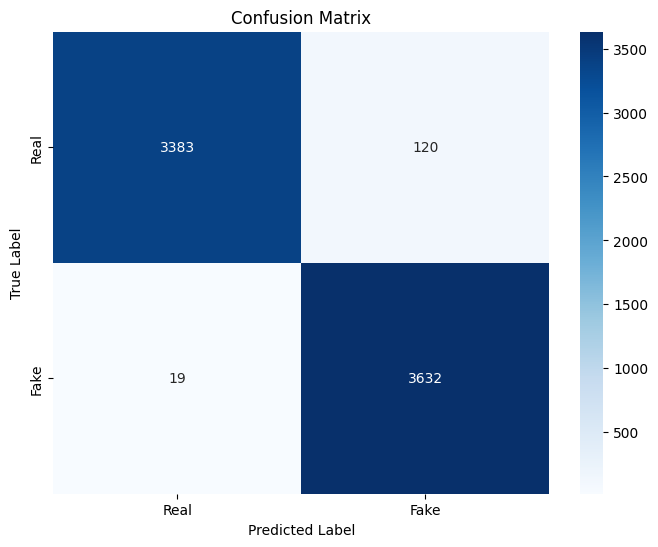

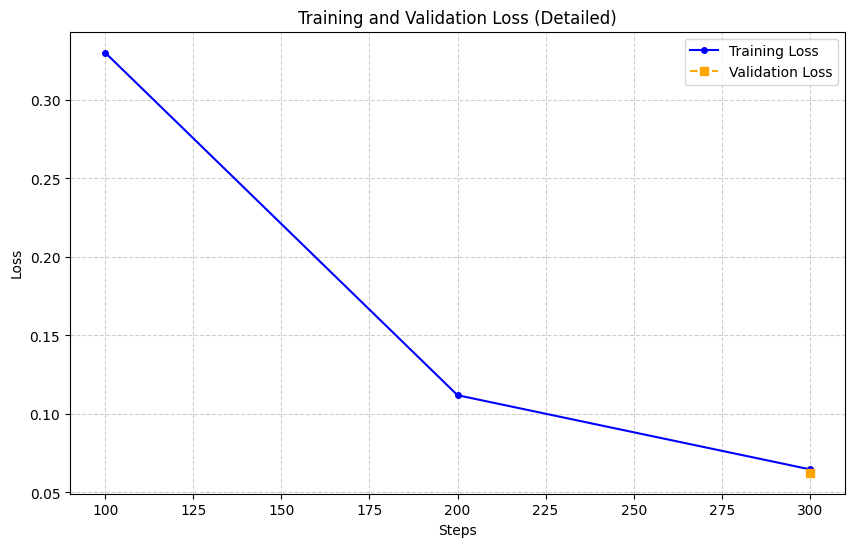

In [ ]:
# 1. Run Evaluation on Test Set
test_results = trainer.predict(tokenized_ds["test"])
y_preds = np.argmax(test_results.predictions, axis=-1)
y_true = tokenized_ds["test"]["label"]

# 2. Print Classification Report
print("FINAL PERFORMANCE ON TEST SET:")
print(classification_report(y_true, y_preds, target_names=['Real News', 'Fake News']))

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()



# 4. Plot Training/Validation Loss
log_history = trainer.state.log_history
train_loss = [x['loss'] for x in log_history if 'loss' in x]
train_steps = [x['step'] for x in log_history if 'loss' in x]

eval_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
eval_steps = [x['step'] for x in log_history if 'eval_loss' in x]

plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_loss, label='Training Loss', color='blue', marker='o', markersize=4)

# Plot validation loss - using the actual steps where evaluation happened
if eval_loss:
    plt.plot(eval_steps, eval_loss, label='Validation Loss', color='orange', linestyle='--', marker='s')

plt.title('Training and Validation Loss (Detailed)')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()